In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, auc, roc_auc_score #混淆矩阵
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score

In [2]:
df=pd.read_csv('creditcard.csv')

In [3]:
print(df.shape)

(284807, 31)


该数据集包含284807行，31列

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

没有空值

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

可见，是严重的类分布不均衡

In [7]:
#分析交易随时间变化是否具有什么特征
df["Time_Hr"] = df["Time"]/3600 # convert to hours

In [8]:
print(df["Time_Hr"].tail()) 

284802    47.996111
284803    47.996389
284804    47.996667
284805    47.996667
284806    47.997778
Name: Time_Hr, dtype: float64


Text(0, 0.5, '# transactions')

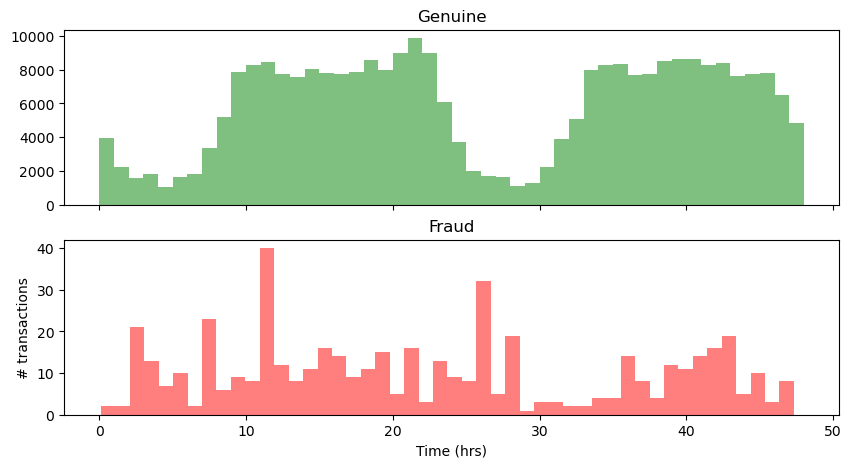

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize=(10,5))
ax1.hist(df.Time_Hr[df.Class==0],bins=48,color='g',alpha=0.5)
ax1.set_title('Genuine')
ax2.hist(df.Time_Hr[df.Class==1],bins=48,color='r',alpha=0.5)
ax2.set_title('Fraud')
plt.xlabel('Time (hrs)')
plt.ylabel('# transactions')

交易通常发生在白天。而且在时间上看不出两个类有很大的差异。因此判断时间对预测交易真假作用不大，后面将时间列删除。但是保留小时这一特征。

In [10]:
df = df.drop(['Time'],axis=1)

Text(0, 0.5, '# transactions')

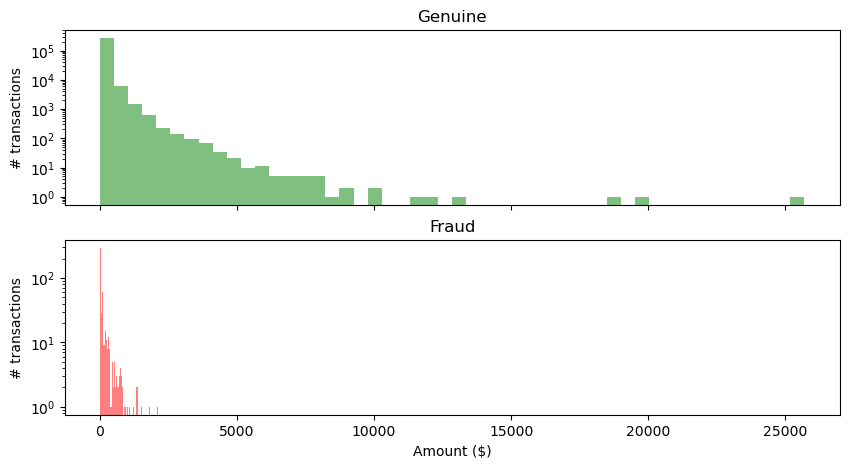

In [11]:
#分析两个类别在消费钱数上有无差别
fig, (ax3,ax4) = plt.subplots(2,1, figsize = (10,5), sharex = True)
ax3.hist(df.Amount[df.Class==0],bins=50,color='g',alpha=0.5)
ax3.set_yscale('log') # to see the tails
ax3.set_title('Genuine') # to see the tails
ax3.set_ylabel('# transactions')
ax4.hist(df.Amount[df.Class==1],bins=50,color='r',alpha=0.5)
ax4.set_yscale('log') # to see the tails
ax4.set_title('Fraud') # to see the tails
ax4.set_xlabel('Amount ($)')
ax4.set_ylabel('# transactions')

可以发现，在虚假交易的消费金额明显比较小，这说明交易金额这一列对预测有用处。下面将对其进行归一化(均值为0，方差为1)。

In [12]:
###Amount列归一化
df['scaled_Amount'] =(df['Amount']-df['Amount'].mean())/df['Amount'].std()

In [13]:
df = df.drop(['Amount'],axis=1)

In [14]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Time_Hr,scaled_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.000000,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.000000,-0.342474
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.000278,1.160684
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.000278,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.000556,-0.073403


In [15]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Time_Hr',
       'scaled_Amount'],
      dtype='object')

假设服从高斯分布，调用GaussianNB函数建立贝叶斯分类模型

In [16]:
from sklearn.model_selection import train_test_split
y = df['Class'].values #target
X = df.drop(['Class'],axis=1).values #features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print("train-set size: ", len(y_train), "\ntest-set size: ", len(y_test))
print("fraud class in train set:",sum(y_train==0))
print("real class in train set:",sum(y_train==1))
print("fraud cases in test-set: ", sum(y_test==0))
print("real cases in test-set: ", sum(y_test==1))

train-set size:  227845 
test-set size:  56962
fraud class in train set: 227451
real class in train set: 394
fraud cases in test-set:  56864
real cases in test-set:  98


In [17]:
from sklearn.naive_bayes import GaussianNB

clf = GaussianNB().fit(X_train,y_train) ###连续变量，假设服从高斯分布，调用GaussianNB函数建立贝叶斯分类模型
# predict using test data
y_pred = clf.predict(X_test)
# Compute predicted probabilities: y_pred_prob
y_pred_prob = clf.predict_proba(X_test)
#for fun: train-set predictions
train_pred = clf.predict(X_train)
print('train-set confusion matrix:\n', confusion_matrix(y_train,train_pred,labels=[1,0])) ###第一个参数放真实的类标签，第二个参数放预测的类标签，第三个参数指定按照1，0的顺序写出混淆矩阵
print("recall score: ", recall_score(y_train,train_pred,pos_label=1)) ###第三个参数指定1是正类
print("precision score: ", precision_score(y_train,train_pred,pos_label=1))
print("f1 score: ", f1_score(y_train,train_pred,pos_label=1))
tp = sum(y_train & train_pred)  
fp = sum((y_train == 0) & (train_pred == 1))
tn = sum((y_train == 0) & (train_pred == 0)) 
fn = sum((y_train == 1) & (train_pred == 0)) 
print('tp:',tp)
print('fp:',fp)
print('fn',fn)
print('tn',tn)

train-set confusion matrix:
 [[   328     66]
 [  4840 222611]]
recall score:  0.8324873096446701
precision score:  0.06346749226006192
f1 score:  0.11794318590435096
tp: 328
fp: 4840
fn 66
tn 222611


In [18]:
y_pred_prob = clf.predict_proba(X_test)
y_pred_prob

array([[0.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 5.20672632e-16],
       [1.00000000e+00, 4.67505942e-17],
       ...,
       [1.00000000e+00, 1.36374013e-15],
       [1.00000000e+00, 2.25254969e-17],
       [9.99999590e-01, 4.09642974e-07]])

要求：使用逻辑回归、神经网络、决策树、随机森林、KNN、朴素贝叶斯
建立分类模型输出每个模型的准确率、召回率、精度、F1指标
画出每个模型的auc曲线

1. 逻辑回归

In [19]:
from sklearn import linear_model, datasets

In [20]:
from sklearn.model_selection import train_test_split
y = df['Class'].values #target
X = df.drop(['Class'],axis=1).values #features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [21]:
logreg=linear_model.LogisticRegression(C=1e5)

In [22]:
logreg.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=100000.0)

In [23]:
y_pred = logreg.predict(X_test)
train_pred = logreg.predict(X_train)

In [24]:
print('train-set confusion matrix:\n', confusion_matrix(y_train,train_pred,labels=[1,0]))

train-set confusion matrix:
 [[   249    145]
 [    30 227421]]


In [25]:
print("score: ", logreg.score(X_test,y_test))
print("recall score: ", recall_score(y_train,train_pred,pos_label=1))
print("precision score: ", precision_score(y_train,train_pred,pos_label=1))
print("f1 score: ", f1_score(y_train,train_pred,pos_label=1))

score:  0.9991222218320986
recall score:  0.631979695431472
precision score:  0.8924731182795699
f1 score:  0.7399702823179791


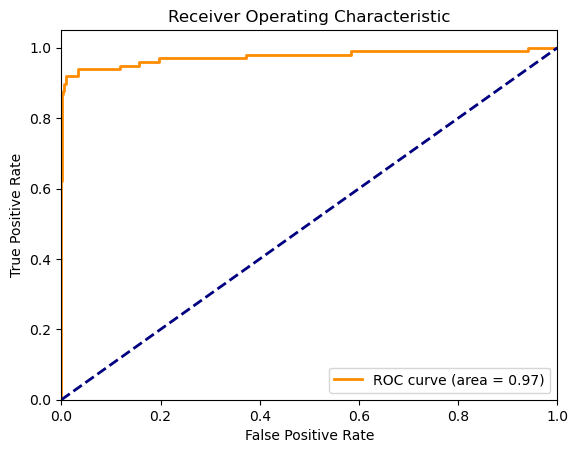

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate the probabilities for the positive class
y_pred_prob = logreg.predict_proba(X_test)[:,1] #每行属于正类别的概率

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) #计算在不同阈值下的FPR和TPR
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [36]:
#y_pred_prob = logreg.predict_proba(X_test)
#y_pred_prob

array([[9.98721157e-01, 1.27884314e-03],
       [9.98537462e-01, 1.46253838e-03],
       [9.99575111e-01, 4.24888650e-04],
       ...,
       [9.99947584e-01, 5.24160327e-05],
       [9.99993323e-01, 6.67743385e-06],
       [9.99724047e-01, 2.75953298e-04]])

2. 神经网络

In [27]:
from sklearn.neural_network import MLPClassifier

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
clf=MLPClassifier(solver='adam',alpha=1e-5,hidden_layer_sizes=(3,3),random_state=1,max_iter=10000,activation='logistic')

In [29]:
clf.fit(X_train,y_train)

MLPClassifier(activation='logistic', alpha=1e-05, hidden_layer_sizes=(3, 3),
              max_iter=10000, random_state=1)

In [30]:
y_pred = clf.predict(X_test)
train_pred = clf.predict(X_train)

In [31]:
print('train-set confusion matrix:\n', confusion_matrix(y_train,train_pred,labels=[1,0]))
print("score: ", clf.score(X_test,y_test))
print("recall score: ", recall_score(y_train,train_pred,pos_label=1))
print("precision score: ", precision_score(y_train,train_pred,pos_label=1))
print("f1 score: ", f1_score(y_train,train_pred,pos_label=1))

train-set confusion matrix:
 [[   269     58]
 [    52 198985]]
score:  0.9992392589211521
recall score:  0.8226299694189603
precision score:  0.838006230529595
f1 score:  0.8302469135802468


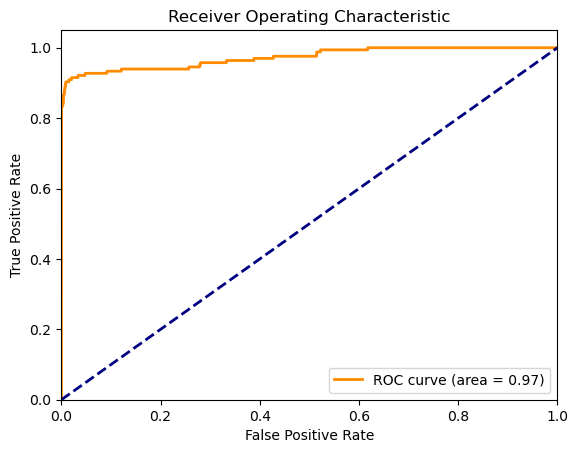

In [32]:
# Calculate the probabilities for the positive class
y_pred_prob = clf.predict_proba(X_test)[:,1] #每行属于正类别的概率

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) #计算在不同阈值下的FPR和TPR
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

3. 决策树

In [33]:
from sklearn import tree
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
dt=tree.DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [34]:
y_pred =dt.predict(X_test)
train_pred = dt.predict(X_train)

In [35]:
print('train-set confusion matrix:\n', confusion_matrix(y_train,train_pred,labels=[1,0]))
print("score: ", dt.score(X_test,y_test))
print("recall score: ", recall_score(y_train,train_pred,pos_label=1))
print("precision score: ", precision_score(y_train,train_pred,pos_label=1))
print("f1 score: ", f1_score(y_train,train_pred,pos_label=1))

train-set confusion matrix:
 [[   343      0]
 [     0 199021]]
score:  0.9991807403766253
recall score:  1.0
precision score:  1.0
f1 score:  1.0


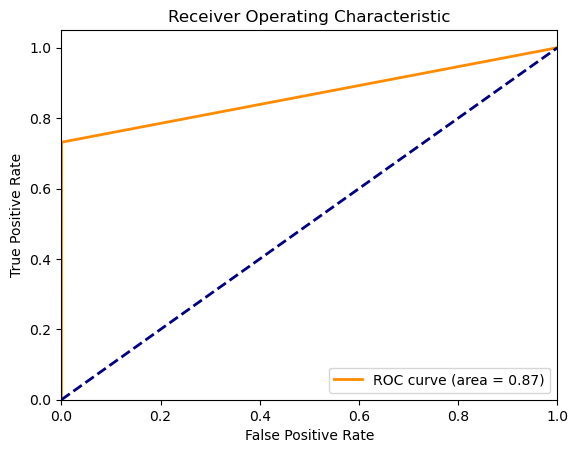

In [36]:
# Calculate the probabilities for the positive class
y_pred_prob = dt.predict_proba(X_test)[:,1] #每行属于正类别的概率

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) #计算在不同阈值下的FPR和TPR
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

4. 随机森林

In [47]:
from sklearn.ensemble import RandomForestClassifier
dt=RandomForestClassifier()
dt.fit(X_train,y_train)

RandomForestClassifier()

In [48]:
y_pred =dt.predict(X_test)
train_pred = dt.predict(X_train)

In [49]:
print('train-set confusion matrix:\n', confusion_matrix(y_train,train_pred,labels=[1,0]))
print("score: ", dt.score(X_test,y_test))
print("recall score: ", recall_score(y_train,train_pred,pos_label=1))
print("precision score: ", precision_score(y_train,train_pred,pos_label=1))
print("f1 score: ", f1_score(y_train,train_pred,pos_label=1))

train-set confusion matrix:
 [[   357      2]
 [     0 199005]]
score:  0.9996254813150287
recall score:  0.9944289693593314
precision score:  1.0
f1 score:  0.9972067039106145


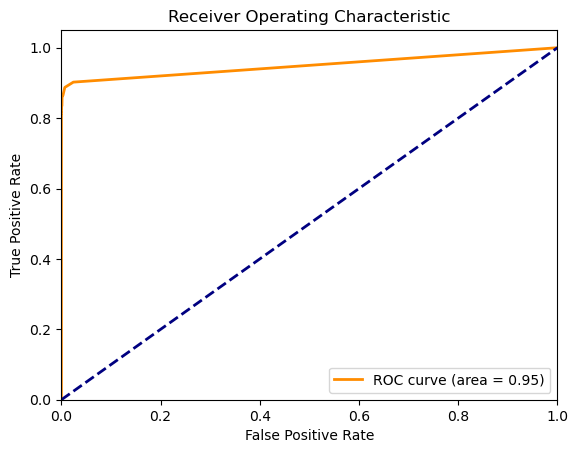

In [50]:
# Calculate the probabilities for the positive class
y_pred_prob = dt.predict_proba(X_test)[:,1] #每行属于正类别的概率

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) #计算在不同阈值下的FPR和TPR
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

5. KNN

In [51]:
from sklearn.neighbors import KNeighborsClassifier
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
KNN_classifier=KNeighborsClassifier(n_neighbors=5)
KNN_classifier.fit(X_train,y_train)

KNeighborsClassifier()

In [52]:
y_pred =KNN_classifier.predict(X_test)
train_pred = KNN_classifier.predict(X_train)

In [53]:
print('train-set confusion matrix:\n', confusion_matrix(y_train,train_pred,labels=[1,0]))
print("score: ", KNN_classifier.score(X_test,y_test))
print("recall score: ", recall_score(y_train,train_pred,pos_label=1))
print("precision score: ", precision_score(y_train,train_pred,pos_label=1))
print("f1 score: ", f1_score(y_train,train_pred,pos_label=1))

train-set confusion matrix:
 [[   298     87]
 [    13 227447]]
score:  0.9994382219725431
recall score:  0.7740259740259741
precision score:  0.9581993569131833
f1 score:  0.8563218390804598


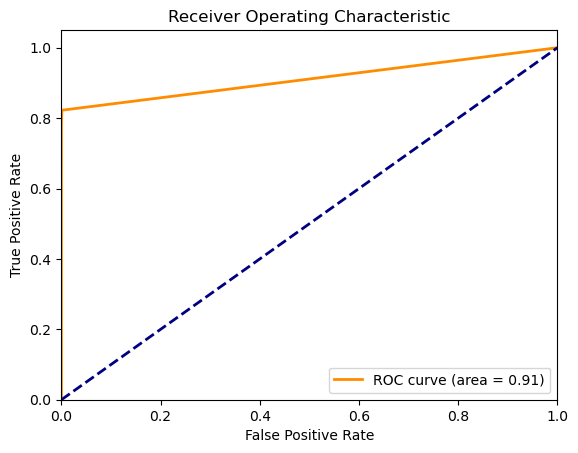

In [56]:
# Calculate the probabilities for the positive class
y_pred_prob = KNN_classifier.predict_proba(X_test)[:,1] #每行属于正类别的概率

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) #计算在不同阈值下的FPR和TPR
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [74]:
#定义一个函数分割数据为训练集和测试集
def split_data(df, drop_list):
    df = df.drop(drop_list,axis=1)
    #print(df.columns)
    #test train split time
    from sklearn.model_selection import train_test_split
    y = df['Class'].values #target
    X = df.drop(['Class'],axis=1).values #features
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)
    return X_train, X_test, y_train, y_test

In [75]:
#定义一个函数做模型预测
def get_predictions(clf, X_train, y_train, X_test):
    # create classifier
    clf = clf
    # fit it to training data
    clf.fit(X_train,y_train)
    # predict using test data
    y_pred = clf.predict(X_test)
    # Compute predicted probabilities: y_pred_prob
    y_pred_prob = clf.predict_proba(X_test)
    #for fun: train-set predictions
    train_pred = clf.predict(X_train)
    print('train-set confusion matrix:\n', confusion_matrix(y_train,train_pred,labels=[1,0])) 
    return y_pred, y_pred_prob

In [76]:
#定义一个函数输出各项分数
def print_scores(y_test,y_pred,y_pred_prob):
    print('test-set confusion matrix:\n', confusion_matrix(y_test,y_pred,labels=[1,0])) 
    print("recall score: ", recall_score(y_test,y_pred,pos_label=1))
    print("precision score: ", precision_score(y_test,y_pred,pos_label=1))
    print("f1 score: ", f1_score(y_test,y_pred,pos_label=1))

In [77]:
# Case-NB-2 : 丢掉一些列， drop some of principle components that have similar distributions in above plots 
drop_list = ['V28','V27','V26','V25','V24','V23','V22','V20','V15','V13','V8']
X_train, X_test, y_train, y_test = split_data(df, drop_list)
y_pred, y_pred_prob = get_predictions(GaussianNB(), X_train, y_train, X_test)
print_scores(y_test,y_pred,y_pred_prob)

train-set confusion matrix:
 [[   333     61]
 [  3484 223967]]
test-set confusion matrix:
 [[   86    12]
 [  929 55935]]
recall score:  0.8775510204081632
precision score:  0.08472906403940887
f1 score:  0.15453728661275834


很明显，删除这些列后，召回率和精度都有所提高